## Задача 4. Реализация метода градиентного спуска

Теперь создадим класс `GradientDescent`, который наследуется от `Gradient` и реализует полный цикл обучения.

**Задачи:**
1. Создай класс `GradientDescent(Gradient)`, который наследует все методы из `Gradient`
2. Добавь метод `optimize(num_iterations, stopping_threshold=0.001, a=0.000001, w_init=0, b_init=0)`:
   - Метод должен итеративно обновлять `w` и `b` с помощью метода `update`
   - Критерии остановки:
     * Превышено количество итераций `num_iterations`
     * Изменение MSE между итерациями меньше `stopping_threshold`
   - Метод должен вернуть словарь с ключами: `'w'`, `'b'`, `'mse'`, `'history'` (список значений MSE на каждой итерации), `'iterations'` (количество выполненных итераций)

3. **Визуализация и анализ:**
   - Обучи модель на данных `X`, `Y` с разными значениями learning rate: `[0.00001, 0.0001]`
   - Для каждого learning rate построй график зависимости MSE от номера итерации
   - На отдельном графике визуализируй финальные линии регрессии для разных learning rate
   - Сделай выводы: какой learning rate работает лучше? Что происходит при слишком большом/малом learning rate?

4. **Сравнение с аналитическим решением:**
   - Сравни полученные градиентным спуском значения с аналитическим решением
   - Визуализируй оба решения на одном графике

In [20]:
class GradientDescent(Gradient):
    def optimize(self, num_iterations=1000, stopping_threshold=1e-6, 
                 a=0.01, w_init=None, b_init=0.0):
        
        if w_init is None:
            w_init = np.zeros(self.n_features)
        else:
            w_init = np.asarray(w_init).flatten()[:self.n_features]
        w = np.asarray(w_init)
        b = float(b_init)
        
        history = []
        prev_mse = float('inf')
        
        for i in range(num_iterations):
            Y_pred = self.predict(w, b)
            mse = self.mse(Y_pred)
            history.append(mse)
            
            if i > 0 and abs(prev_mse - mse) < stopping_threshold:
                break
                
            w, b = self.update(w, b, a)
            prev_mse = mse
        
        return {
            'w': w,
            'b': b,
            'mse': self.mse(self.predict(w, b)),
            'history': history,
            'iterations': len(history)
        }


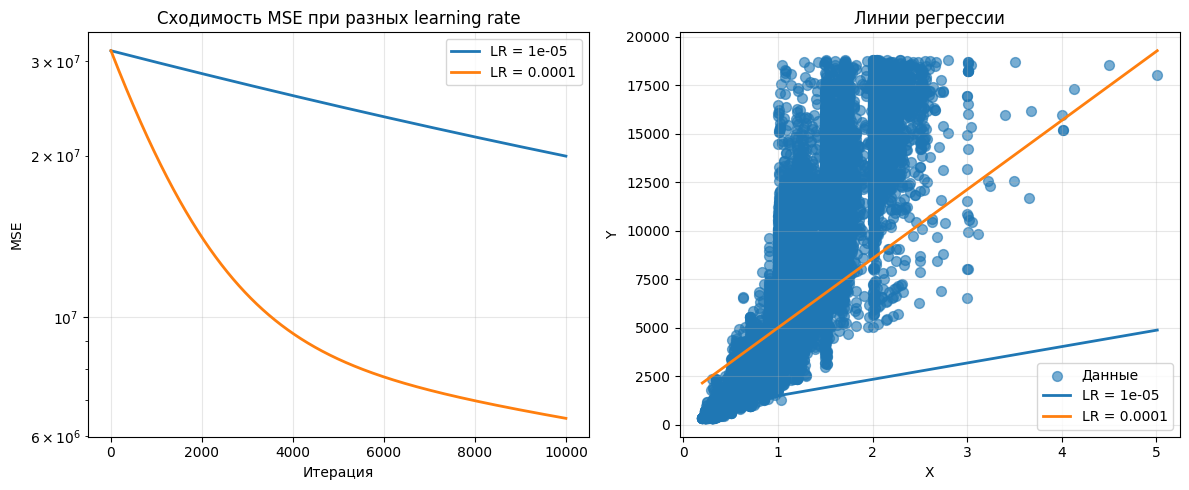

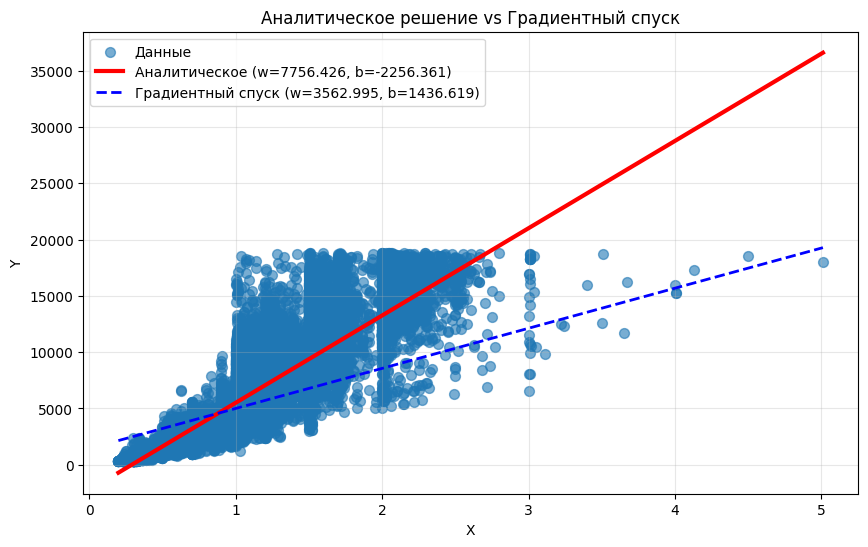

In [21]:
learning_rates = [0.00001, 0.0001]

results = {}
for lr in learning_rates:
    gd = GradientDescent(X, y)
    result = gd.optimize(num_iterations=10000, stopping_threshold=0.0001, a=lr, w_init=0, b_init=0)
    results[lr] = result

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for lr in learning_rates:
    history = results[lr]['history']
    plt.plot(history, label=f'LR = {lr}', linewidth=2)

plt.xlabel('Итерация')
plt.ylabel('MSE')
plt.title('Сходимость MSE при разных learning rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

plt.subplot(1, 2, 2)
plt.scatter(X, y, alpha=0.6, label='Данные', s=50)

x_line = np.linspace(X.min(), X.max(), 100)
for lr in learning_rates:
    w = results[lr]['w']
    b = results[lr]['b']
    y_line = w * x_line + b
    plt.plot(x_line, y_line, label=f'LR = {lr}', linewidth=2)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Линии регрессии')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

x_mean = np.mean(X)
y_mean = np.mean(y)
w_analytical = np.sum((X - x_mean) * (y - y_mean)) / np.sum((X - x_mean)**2)
b_analytical = y_mean - w_analytical * x_mean

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, label='Данные', s=50)

x_line = np.linspace(X.min(), X.max(), 100)

# Аналитическое
y_analytical = w_analytical * x_line + b_analytical
plt.plot(x_line, y_analytical, 'r-', linewidth=3, 
         label=f'Аналитическое (w={w_analytical:.3f}, b={b_analytical:.3f})')

w_gd = results[0.0001]['w']
b_gd = results[0.0001]['b']
y_gd = w_gd * x_line + b_gd
plt.plot(x_line, y_gd, 'b--', linewidth=2, 
         label=f'Градиентный спуск (w={w_gd[0]:.3f}, b={b_gd:.3f})')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Аналитическое решение vs Градиентный спуск')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Задача 5. Масштаб признаков и StandardScaler

Сейчас наш датасет содержит только одну фичу — **площадь квартиры** (примерно 30–120 м²).  
Мы добавляем вторую фичу — **расстояние до центра города** (в км, масштаб 0–30 км),  
при этом **не приводим признаки к одному масштабу**.

1. Обучите линейную регрессию **градиентным спуском** в двух вариантах:

   **Вариант А** — на исходных данных (без масштабирования)  
   **Вариант Б** — после стандартизации признаков (StandardScaler / (X - mean)/std)

2. Сравните результаты обоих экспериментов по следующим пунктам:

   - Количество итераций до сходимости  
   - Значения весов w₁ и w₂ (насколько близко к истинным значениям?)  
   - Финальное значение MSE  
   - Поведение графика сходимости (есть ли NaN, взрывы, медленная сходимость?)

In [9]:
np.random.seed(42)

n = 100

# Первая фича: площадь (30–120 м²)
X1 = np.random.rand(n, 1) * 90 + 30

# Вторая фича: расстояние до центра (в км) — от 0 до 10 км
X2 = np.random.rand(n, 1) * 10

X_new = np.hstack([X1, X2])
true_w1 = 1200      # цена за м²
true_w2 = -3500     # минус 3500 руб за каждый км от центра
true_intercept = 45000

# Целевая переменная
y_new = (true_intercept 
     + true_w1 * X1 
     + true_w2 * X2 
     + np.random.randn(n, 1) * 18000)

In [10]:
gd_raw = GradientDescent(X_new, y_new)

result_raw = gd_raw.optimize(
    num_iterations=5000,
    stopping_threshold=0.0001,
    a=0.0001
)

print("Без масштабирования:")
print(f"  w1 = {result_raw['w'][0]:8.2f}, w2 = {result_raw['w'][1]:8.2f}")
print(f"  b  = {result_raw['b']:8.2f}")
print(f"  MSE = {result_raw['mse']:8.2f}")
print(f"  Итераций: {result_raw['iterations']}\n")

Без масштабирования:
  w1 =  1504.74, w2 =    28.20
  b  =  3763.40
  MSE = 456010634.71
  Итераций: 5000



In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_new)

gd_scaled = GradientDescent(X_scaled, y_new)

result_scaled = gd_scaled.optimize(
    num_iterations=5000,
    stopping_threshold=0.0001,
    a=0.01
)

print("После стандартизации:")
print(f"  w1 = {result_scaled['w'][0]:8.2f}, w2 = {result_scaled['w'][1]:8.2f}")
print(f"  b  = {result_scaled['b']:8.2f}")
print(f"  MSE = {result_scaled['mse']:8.2f}")
print(f"  Итераций: {result_scaled['iterations']}")

После стандартизации:
  w1 = 30147.09, w2 = -6431.41
  b  = 116299.96
  MSE = 306397667.16
  Итераций: 730


## Логистическая регрессия

Кроме задачи регрессии линейные алгоритмы способны также решать задачу **классификации**.  
Для этого используется **логистическая регрессия** — один из самых популярных и понятных методов бинарной классификации.

### Основные отличия от линейной регрессии

Линейная регрессия предсказывает **непрерывные значения** (любое вещественное число),  
а логистическая регрессия — **вероятность принадлежности** к одному из двух классов (обычно 0 или 1).

- Выход модели — вероятность от 0 до 1  
- Функция активации — сигмоида:  
  $$\hat{y} = \sigma(z) = 1 / (1 + e^{-z}) $$ 
- Функция потерь — Log Loss (бинарная кросс-энтропия)

### Как работает логистическая регрессия

1. Считаем линейную комбинацию признаков (как обычно):  
   $$z = w_0 + w_1x_1 + w_2x_2 + … + w_2x_2$$

2. Применяем сигмоиду, чтобы получить вероятность:  
   $$P(y = 1|x) = \hat{y} = 1 / (1 + e^{-z})$$

3. Принимаем решение по порогу (чаще всего 0.5):  
   $$\hat{y} \ge 0.5 → \text{класс 1}$$
   $$\hat{y} < 0.5 → \text{класс 0}$$

### Функция потерь (Log Loss)

Для одного примера:

$$L = –[ y \cdot \log(\hat{y}) + (1 – y) \cdot \log(1 – \hat{y}) ]$$

Чем ближе предсказанная вероятность ŷ к реальному классу y, тем меньше значение потерь.

## Задача 6. Логистическая регрессия

В этом задании тебе нужно будеть обучить модель логистической регрессии и построить разделяющую плоскость

1. **Обучить модель логистической регрессии**  
   - Использовать `LogisticRegression` из `sklearn.linear_model`  
   - Рекомендуемые параметры:  
     - `penalty=None` (без регуляризации для чистоты эксперимента)  
     - `solver='lbfgs'` или `'liblinear'`  
   - Обучить модель на полученных данных  
   - Вывести коэффициенты: `coef_` и `intercept_`  
   - Посчитать точность (`model.score(X, y)`)

2. **Визуализировать результаты**  
   - Построить scatter plot: точки двух классов разными цветами  
   - Нарисовать разделяющую прямую по уравнению:  
   - Добавить:  
     - легенду  
     - подписи осей  
     - заголовок  
     - сетку  
   - (Опционально) Залить цветом области принятия решений для каждого класса

In [19]:
X_cls, y_cls = make_classification(n_samples=400, n_features=2, n_informative=2,
                          n_redundant=0, n_clusters_per_class=1, 
                          class_sep=1.8, random_state=42)


In [20]:
clf = LogisticRegression()
clf.fit(X_cls, y_cls)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


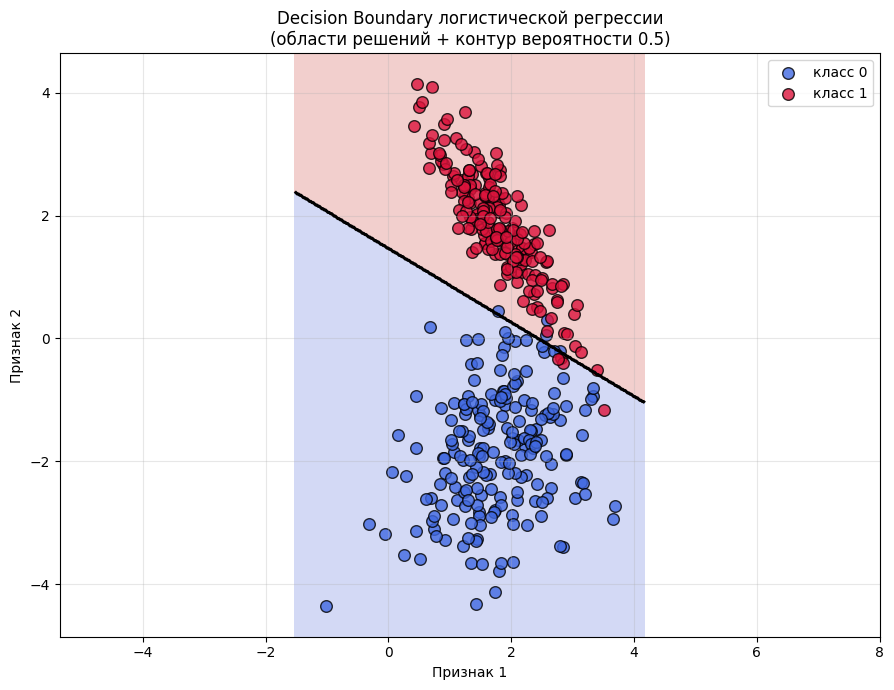

In [26]:
h = 0.02  # шаг сетки
x_min, x_max = X_cls[:, 0].min() - 0.5, X_cls[:, 0].max() + 0.5
y_min, y_max = X_cls[:, 1].min() - 0.5, X_cls[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(9, 7))

# Заливка областей решений
plt.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')

# Контур разделяющей линии (уровень 0.5)
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2.2, linestyles='-')

# Точки данных
plt.scatter(X_cls[y_cls==0,0], X_cls[y_cls==0,1], c='royalblue', s=70, edgecolor='k', alpha=0.8, label='класс 0')
plt.scatter(X_cls[y_cls==1,0], X_cls[y_cls==1,1], c='crimson', s=70, edgecolor='k', alpha=0.8, label='класс 1')

plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title('Decision Boundary логистической регрессии\n(области решений + контур вероятности 0.5)')
plt.legend()
plt.grid(alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

## Задача 7. Lasso регуляризация

**Регуляризация Lasso (Least Absolute Shrinkage and Selection Operator)** — это техника, которая добавляет штраф за абсолютное значение весов к функции потерь. Это помогает:
- Бороться с переобучением
- Выполнять отбор признаков (обнулять неважные веса)
- Упрощать модель

**Функция потерь с L1-регуляризацией:**

$$L(\mathbf{w}, b) = \frac{1}{N} \sum_{i=1}^{N} (y_i - (\mathbf{w}^T \mathbf{x}_i + b))^2 + \lambda \sum_{j=1}^{n} |w_j|$$

где $\lambda$ — параметр регуляризации.

**Градиенты с учетом регуляризации:**

$$\frac{\partial L}{\partial w_j} = -\frac{2}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i) \cdot x_{ij} + \lambda \cdot \text{sign}(w_j)$$

$$\frac{\partial L}{\partial b} = -\frac{2}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)$$

где $\text{sign}(w_j) = 1$ если $w_j > 0$, $-1$ если $w_j < 0$, и $0$ если $w_j = 0$.

**Задачи:**
1. Создай класс `LassoGradientDescent(Gradient)`, который наследуется от `Gradient`
2. Переопредели метод `update(w, b, a=0.0001, lambda_reg=0.01)`:
   - Добавь L1-регуляризацию к градиентам весов
   - Используй функцию `np.sign()` для вычисления знака весов
   - Обнови параметры с учетом регуляризации

3. Реализуй метод `optimize` аналогично заданию 5, но с параметром `lambda_reg`

4. **Эксперименты:**
   - Создай синтетический датасет с несколькими признаками, где некоторые признаки не важны
   - Обучи модель с разными значениями $\lambda$: `[0.001, 0.01, 0.1, 1.0, 10.0]`
   - Построй график зависимости весов от значения $\lambda$ (Lasso path)
   - Визуализируй, как веса обнуляются при увеличении $\lambda$
   - Сравни с обычной линейной регрессией без регуляризации
   - Сделай выводы: при каком $\lambda$ модель лучше работает? Какие признаки отбираются?

> **Примечание:** Lasso особенно полезен, когда у нас много признаков, и мы хотим понять, какие из них действительно важны.


In [27]:
np.random.seed(42)
n_samples = 100
n_features = 5
X_multi = np.random.randn(n_samples, n_features)
true_weights = np.array([2.0, 1.5, 0.0, 0.0, 0.0])
true_bias = 1.0
Y_multi = X_multi @ true_weights + true_bias + np.random.randn(n_samples) * 0.5

In [28]:
class LassoGradientDescent:
    def __init__(self, X, Y):
        self.X = np.asarray(X)
        self.Y = np.asarray(Y).flatten()
        self.N, self.n_features = self.X.shape
    
    def predict(self, w, b):
        return self.X @ w + b
    
    def mse(self, Y_pred):
        return np.mean((self.Y - Y_pred)**2)
    
    def update(self, w, b, a=0.001, lambda_reg=0.01):
        Y_pred = self.predict(w, b)
        errors = self.Y - Y_pred  # shape: (N,)
        
        # Градиент MSE
        grad_w_mse = -2 / self.N * (self.X.T @ errors)  # shape: (n_features,)
        grad_b = -2 / self.N * np.sum(errors)
        
        # Градиент L1-регуляризации (субградиент)
        grad_w_reg = lambda_reg * np.sign(w)
        
        # Полный градиент
        grad_w = grad_w_mse + grad_w_reg
        
        # Обновление
        w_new = w - a * grad_w
        b_new = b - a * grad_b
        
        return w_new, b_new
    
    def optimize(self, num_iterations=10000, a=0.001, lambda_reg=0.01, tol=1e-6):
        w = np.zeros(self.n_features)
        b = 0.0
        prev_mse = float('inf')
        
        for i in range(num_iterations):
            w, b = self.update(w, b, a=a, lambda_reg=lambda_reg)
            current_mse = self.mse(self.predict(w, b))
            
            if abs(prev_mse - current_mse) < tol:
                break
            prev_mse = current_mse
        
        return {'w': w, 'b': b, 'mse': prev_mse, 'iterations': i+1}

In [29]:
lambdas = [0.0001, 0.001, 0.01, 0.1, 1.0, 5.0, 10.0]

weights_path = []
mses = []

for lam in lambdas:
    lasso = LassoGradientDescent(X_multi, Y_multi)
    result = lasso.optimize(a=0.0005, lambda_reg=lam, num_iterations=20000)
    weights_path.append(result['w'])
    mses.append(result['mse'])
    print(f"λ = {lam:6.4f} | MSE = {result['mse']:.4f} | итераций: {result['iterations']}")

weights_path = np.array(weights_path)

λ = 0.0001 | MSE = 0.2016 | итераций: 6361
λ = 0.0010 | MSE = 0.2016 | итераций: 6372
λ = 0.0100 | MSE = 0.2019 | итераций: 6507
λ = 0.1000 | MSE = 0.2138 | итераций: 7007
λ = 1.0000 | MSE = 1.1047 | итераций: 3322
λ = 5.0000 | MSE = 4.9212 | итераций: 20000
λ = 10.0000 | MSE = 4.9212 | итераций: 20000


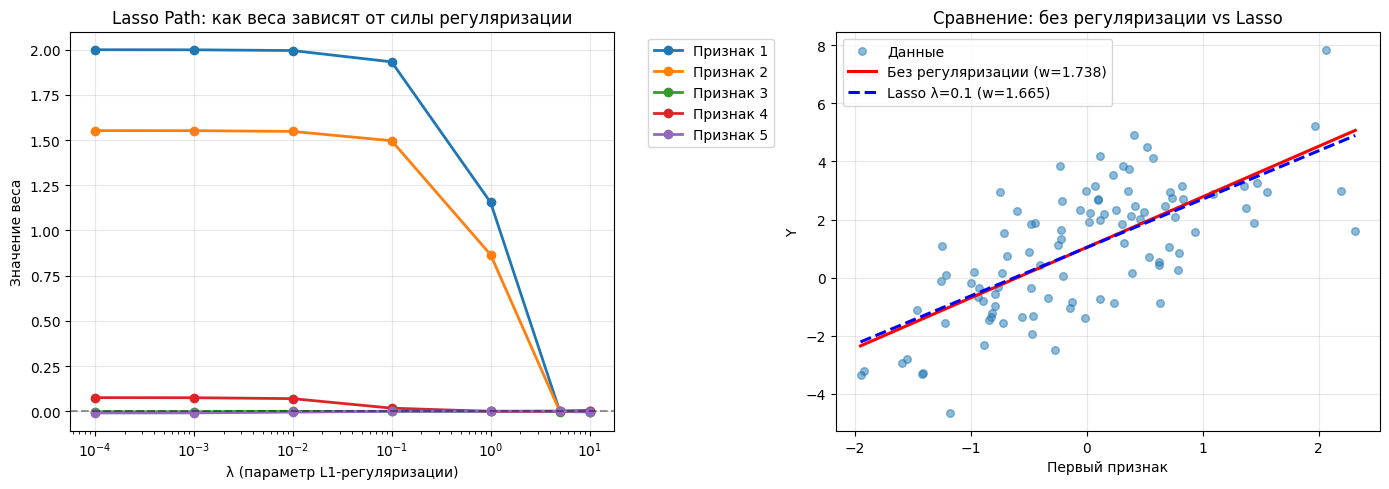

In [36]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for i in range(X_multi.shape[1]):
    plt.plot(lambdas, weights_path[:, i], 'o-', 
             label=f'Признак {i+1}', linewidth=2, markersize=6)

plt.axhline(y=0, color='k', linestyle='--', alpha=0.4)
plt.xscale('log')
plt.xlabel('λ (параметр L1-регуляризации)')
plt.ylabel('Значение веса')
plt.title('Lasso Path: как веса зависят от силы регуляризации')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# ─── Сравнение линий (без регуляризации vs Lasso) ─────────────────────
plt.subplot(1, 2, 2)

plt.scatter(X_multi[:, 0], Y_multi, alpha=0.5, s=30, label='Данные')

x_line = np.linspace(X_multi[:, 0].min(), X_multi[:, 0].max(), 120)

# Без регуляризации (обычный градиентный спуск)
X_1d = X_multi[:, 0].reshape(-1, 1)
lr = LinearRegression()
lr.fit(X_1d, Y_multi)
y_no_reg = lr.predict(x_line.reshape(-1, 1))

lasso = LassoGradientDescent(X_multi[:, [0]], Y_multi)
res_lasso = lasso.optimize(a=0.0005, lambda_reg=0.1)
y_lasso = res_lasso['w'][0] * x_line + res_lasso['b']

plt.plot(x_line, y_no_reg, 'r-', lw=2.2, 
         label=f'Без регуляризации (w={lr.coef_[0]:.3f})')
plt.plot(x_line, y_lasso, 'b--', lw=2.2, 
         label=f'Lasso λ=0.1 (w={res_lasso["w"][0]:.3f})')

plt.xlabel('Первый признак')
plt.ylabel('Y')
plt.title('Сравнение: без регуляризации vs Lasso')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()